In [1]:
import os
import sys
import warnings
from pathlib import Path

import cartopy.crs as ccrs
import cmocean as cmo
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import metpy.constants as mpconst
import numpy as np
import xarray as xr

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    sys.path.insert(1, "../onset_identification")
from utils import (
    domains,
    get_nn_lon_lat_index,
    haversine,
    hp_mods,
    hp_to_latlon,
    ifs_hp_mods,
    relon,
    sim_colors,
    sim_labels,
    sims,
    sims_new,
    um_sims,
)


def calculate_mse(
    temperature,
    geopotential_height,
    specific_humidity,
):
    g = mpconst.g.magnitude
    cp = mpconst.dry_air_spec_heat_press.magnitude
    Lv = mpconst.water_heat_vaporization.magnitude

    # compute h
    return cp * temperature + geopotential_height + Lv * specific_humidity


def mass_weighted_column_integral(da, sfc_p):
    da = da.sortby("pressure")
    g = mpconst.g.magnitude
    p = da["pressure"].values.astype(float)  # 1D mid-level pressures (Pa)

    # build interface/bound values (half-levels)
    mid = 0.5 * (p[1:] + p[:-1])
    bounds = np.concatenate(
        ([p[0] - 0.5 * (p[1] - p[0])], mid, [p[-1] + 0.5 * (p[-1] - p[-2])])
    )

    # finding the higher p_hi and lower p_lo pressure of the bounds
    p_hi = np.maximum(bounds[:-1], bounds[1:])
    p_lo = np.minimum(bounds[:-1], bounds[1:])

    # create 1d das for broadcasting
    p_hi_da = xa.DataArray(p_hi, coords={"pressure": p}, dims=["pressure"])
    p_lo_da = xa.DataArray(p_lo, coords={"pressure": p}, dims=["pressure"])

    # compute effective dp for each layer at every horizontal grid point:
    #             dp_eff = max(0, min(p_hi, p_sfc) - p_lo)
    # -> for each level, if the higher (below) pressure bound is smaller
    #    than (above) the surface pressure, take p_hi-p_lo the normal bound
    # -> if the higher (below) pressure bound is larger than (below) surface
    #    pressure, take p_sfc-p_lo as the band
    # -> if that gives a negative value, p_sfc is smaller than p_lo, meaning
    #    that the entire band is below the surface so we should set it to 0.

    # p_top_da has dim 'pressure' and sfc_p_da has e.g. ('lat','lon')
    dp_eff = (np.minimum(p_hi_da, sfc_p) - p_lo_da).clip(min=0)

    int_da = (da * dp_eff).sum(dim="pressure") / g

    return int_da


def calc_meridional_energy_flux(vH):
    R_e = mpconst.earth_avg_radius.magnitude
    vH_rad = vH.assign_coords({"longitude": np.deg2rad(vH["longitude"])})
    vH_int = vH_rad.integrate(coord="longitude")
    f_total = vH_int * R_e * np.cos(np.deg2rad(vH["latitude"]))
    f_total.name = "meridional_energy_flux"
    f_total.attrs["units"] = "W"
    return f_total

print("yes")

yes


## era5 test

In [2]:
era5_path = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
full_era5 = xr.open_zarr(era5_path, chunks=None, storage_options=dict(token="anon"))
era5_dyperiod=full_era5.sel(time=slice("2020-03-01", "2020-03-31"))

In [3]:
va = era5_dyperiod.v_component_of_wind
ta = era5_dyperiod.temperature
hus = era5_dyperiod.specific_humidity
zg = era5_dyperiod.geopotential
sp = era5_dyperiod.surface_pressure

In [4]:
h = calculate_mse(ta, zg, hus)
H = mass_weighted_column_integral(h, ps)
vH = mass_weighted_column_integral(va * h)
monthly_energy_flux = calc_meridional_energy_flux(vH).resample(time="1ME").mean()

In [ ]:
    plot = monthly_energy_flux.plot(col="time", col_wrap=4,)
    plot.map(lambda: plt.grid(True))

## now these godawful simulations

In [2]:
url = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
cat = intake.open_catalog(url)["online"]
zoom = 3
sim=sims_new[-1]
sim_cat = cat[sim]
ds = sim_cat(zoom=7).to_dask().pipe(egh.attach_coords)

In [4]:
ds.tp

<xarray.DataArray 'tp' (time: 10201, value: 196608)> Size: 16GB
dask.array<open_dataset-tp, shape=(10201, 196608), dtype=float64, chunksize=(85, 196608), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 82kB 2020-01-01 ... 2021-03-01
    crs      int64 8B 0
Dimensions without coordinates: value
Attributes: (12/15)
    paramId:                    228
    dataType:                   fc
    numberOfPoints:             196608
    typeOfLevel:                surface
    stepUnits:                  1
    stepType:                   accum
    ...                         ...
    name:                       Total precipitation
    cfVarName:                  tp
    missingValue:               9999
    NV:                         0
    gridDefinitionDescription:  150
    grid_mapping:               crs

In [34]:
[ds[var].long_name for var in ds]

['atmosphere_mass_content_of_cloud_ice',
 'cloud_area_fraction',
 'atmosphere_mass_content_of_cloud_condensed_water',
 'surface_downward_latent_heat_flux',
 'surface_downward_sensible_heat_flux',
 'specific_humidity',
 'mass_content_of_water_in_soil_layer',
 'surface_altitude',
 'precipitation_flux',
 'solid_precipitation_flux',
 'atmosphere_mass_content_of_water_vapor',
 'surface_air_pressure',
 'air_pressure_at_mean_sea_level',
 'surface_downwelling_longwave_flux_in_air',
 'surface_downwelling_longwave_flux_in_air_assuming_clear_sky',
 'surface_upwelling_longwave_flux_in_air',
 'toa_outgoing_longwave_flux',
 'toa_outgoing_longwave_flux_assuming_clear_sky',
 'surface_downwelling_shortwave_flux_in_air',
 'surface_downwelling_shortwave_flux_in_air_assuming_clear_sky',
 'toa_incoming_shortwave_flux',
 'surface_upwelling_shortwave_flux_in_air',
 'toa_outgoing_shortwave_flux',
 'toa_outgoing_shortwave_flux_assuming_clear_sky',
 'land_area_fraction',
 'air_temperature',
 'surface_temperatur

<Figure size 640x480 with 0 Axes>

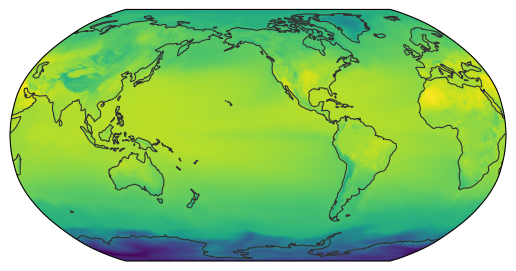

In [21]:
egh.healpix_show(ds.ts.isel(time=243))

In [3]:
url = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
cat = intake.open_catalog(url)["online"]
zoom = 3

for sim in sims[2:]:
    sim_cat = cat[sim]
    print(sim)
    
    if "hk26" in sim:
        ds = sim_cat(zoom=zoom, time="PT3H").to_dask().pipe(hp_mods)
    else:
        if "icon" in sim:
            ds = (
                sim_cat(zoom=zoom, time="P1D", time_method="mean")
                .to_dask()
                .pipe(egh.attach_coords)
            )
        elif "nicam" in sim or "cas" in sim:
            ds = sim_cat(zoom=zoom, time="PT6H").to_dask().pipe(egh.attach_coords)
        elif "ifs" in sim:
            zoom = 7
            ds = sim_cat(zoom=zoom,dim="3D").to_dask().pipe(ifs_hp_mods)
            ds=ds.rename({"u":"ua","v":"va","q":"hus","t":"ta","z":"zg"})
        else:
            ds = sim_cat(zoom=zoom,).to_dask().pipe(egh.attach_coords)
    ds = hp_to_latlon(ds.sel(time=slice("2020-03-01", "2021-02-28")), zoom)
    if max(ds.longitude) > 180:
        ds = relon(ds).sortby("longitude")
    
    h = calculate_mse(ds.ta, ds.zg, ds.hus)
    H = mass_weighted_column_integral(h,ds.ps)
    vH = mass_weighted_column_integral(ds.va * h)
    monthly_energy_flux = (
        calc_meridional_energy_flux(vH)
        .resample(time="1ME")
        .mean()
    )
    plot = monthly_energy_flux.plot(col="time", col_wrap=4,)
    plot.map(lambda: plt.grid(True))
    plt.suptitle(sim)
    plt.savefig(f"{sim}.png")

casesm2_10km_nocumulus


In [ ]:
url = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
cat = intake.open_catalog(url)["online"]
zoom = 3

for sim in sims:
    sim_cat = cat[sim]
    
    if "hk26" in sim:
        ds = sim_cat(zoom=zoom, time="PT3H").to_dask().pipe(hp_mods)
    else:
        if "icon" in sim:
            ds = (
                sim_cat(zoom=zoom, time="P1D", time_method="mean")
                .to_dask()
                .pipe(egh.attach_coords)
            )
        elif "nicam" in sim:
            ds = sim_cat(zoom=zoom, time="PT6H").to_dask().pipe(egh.attach_coords)
        elif "ifs" in sim:
            zoom = 7
            ds = sim_cat(zoom=7,dim="3D").to_dask().pipe(ifs_hp_mods)
            ds=ds.rename({"u":"ua","v":"va","q":"hus","t":"ta","z":"zg"})
        else:
            ds = sim_cat(zoom=zoom,).to_dask().pipe(egh.attach_coords)
    ds = hp_to_latlon(ds, zoom)
    if max(ds.longitude) > 180:
        ds = relon(ds).sortby("longitude")
    
    h = calculate_mse(ds.ta, ds.zg, ds.hus)
    H = mass_weighted_column_integral(h).resample(time="1ME").mean()
    vH = mass_weighted_column_integral(ds.va.resample(time="1ME").mean() * h)
    monthly_energy_flux = (
        calc_meridional_energy_flux(vH)
        .sel(time=slice("2020-03-01", "2021-02-28"))
    )
    monthly_energy_flux.plot(col="time", col_wrap=4,grid=True)
    plt.suptitle(sim)
    plt.savefig(f"{sim}.png")

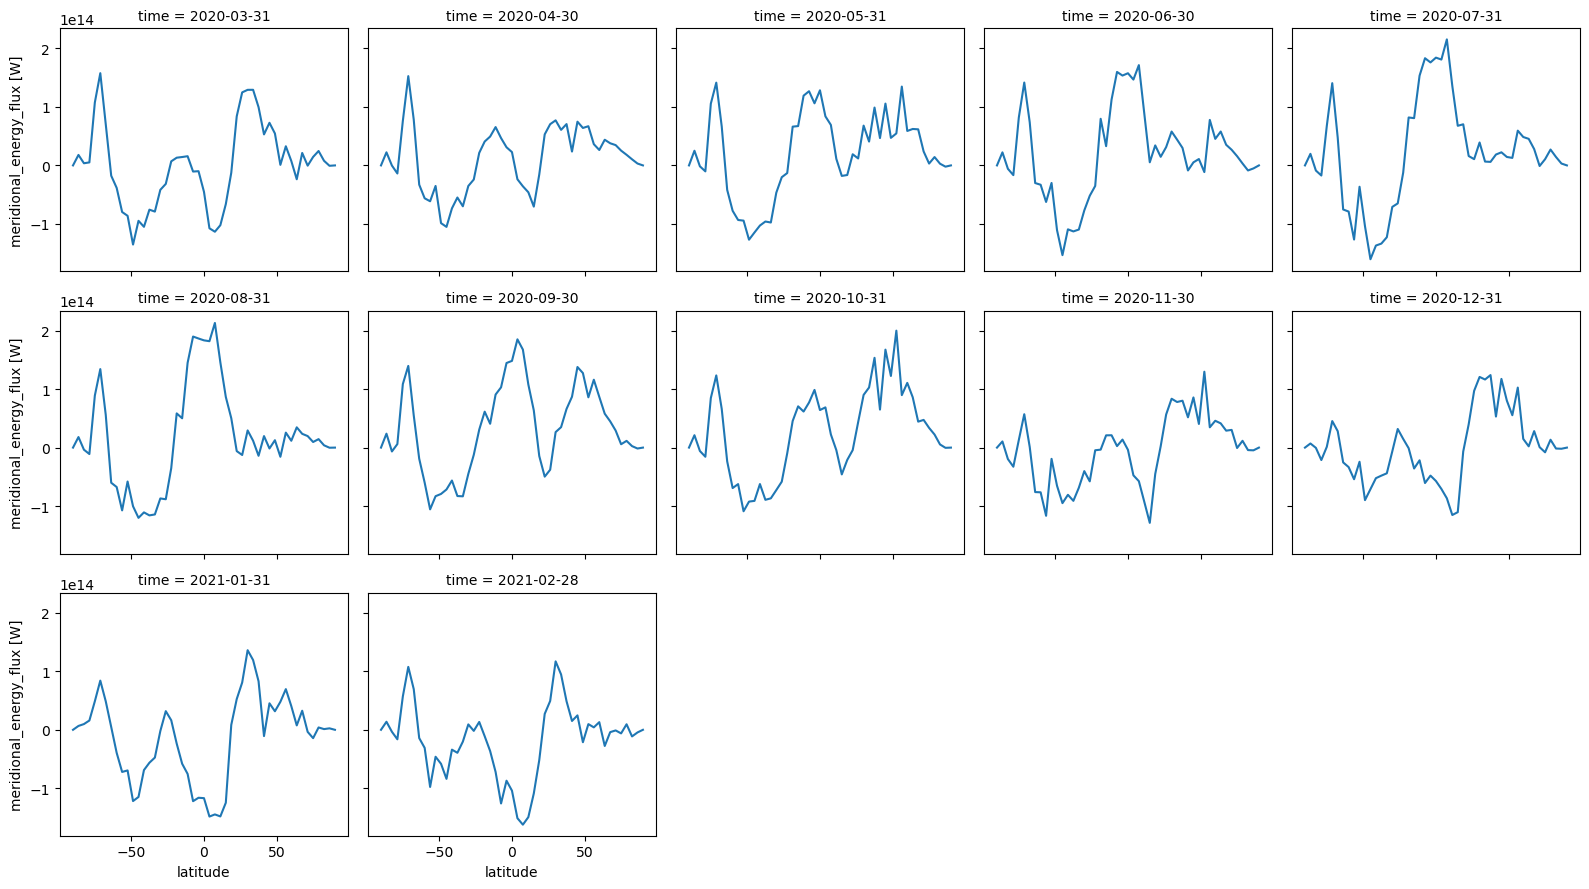

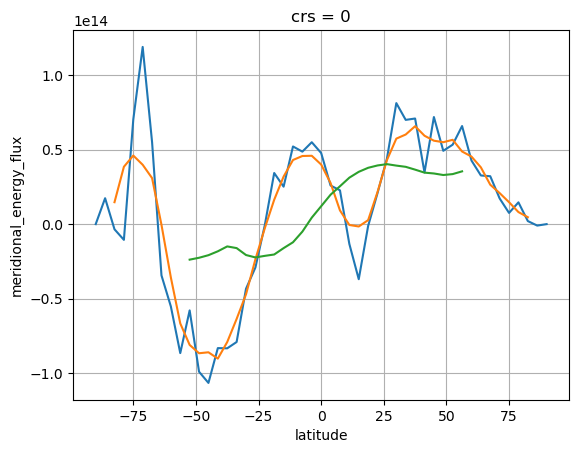

In [65]:
calc_meridional_energy_flux(vH).sel(time=slice("2020-03-01", "2021-02-28")).mean(
    dim="time"
).plot()
calc_meridional_energy_flux(vH).sel(time=slice("2020-03-01", "2021-02-28")).mean(
    dim="time"
).rolling(latitude=5,center=True).mean().plot()
calc_meridional_energy_flux(vH).sel(time=slice("2020-03-01", "2021-02-28")).mean(
    dim="time"
).rolling(latitude=20,center=True).mean().plot()
plt.grid()

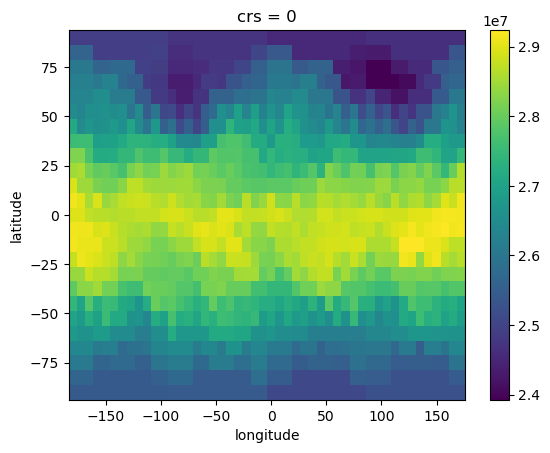

In [34]:
H.sel(time="2020-02-25").mean(dim="time").plot()

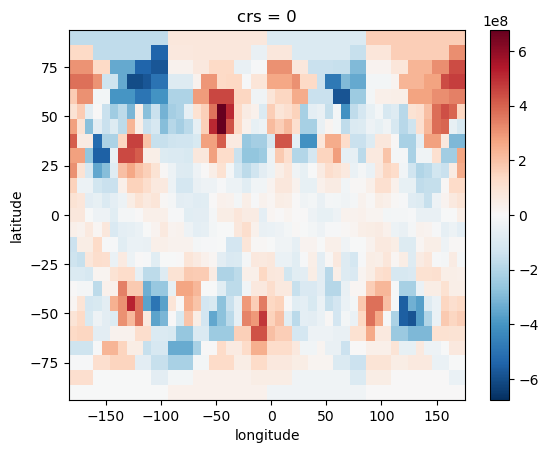

In [12]:
vH.sel(time="2020-02-25").mean(dim="time").plot()


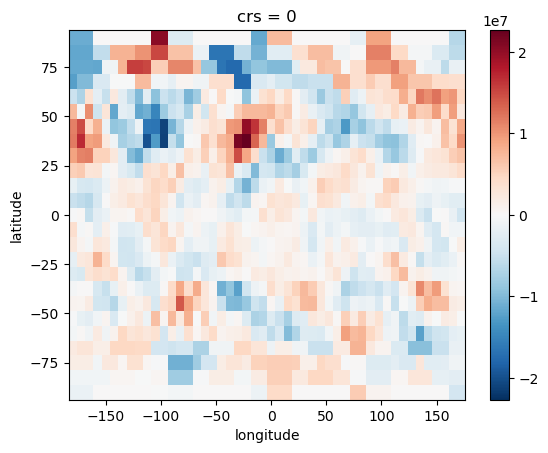

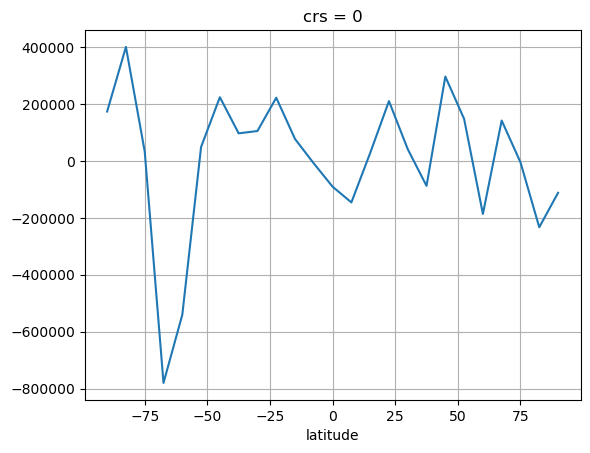

# Visualising existing files

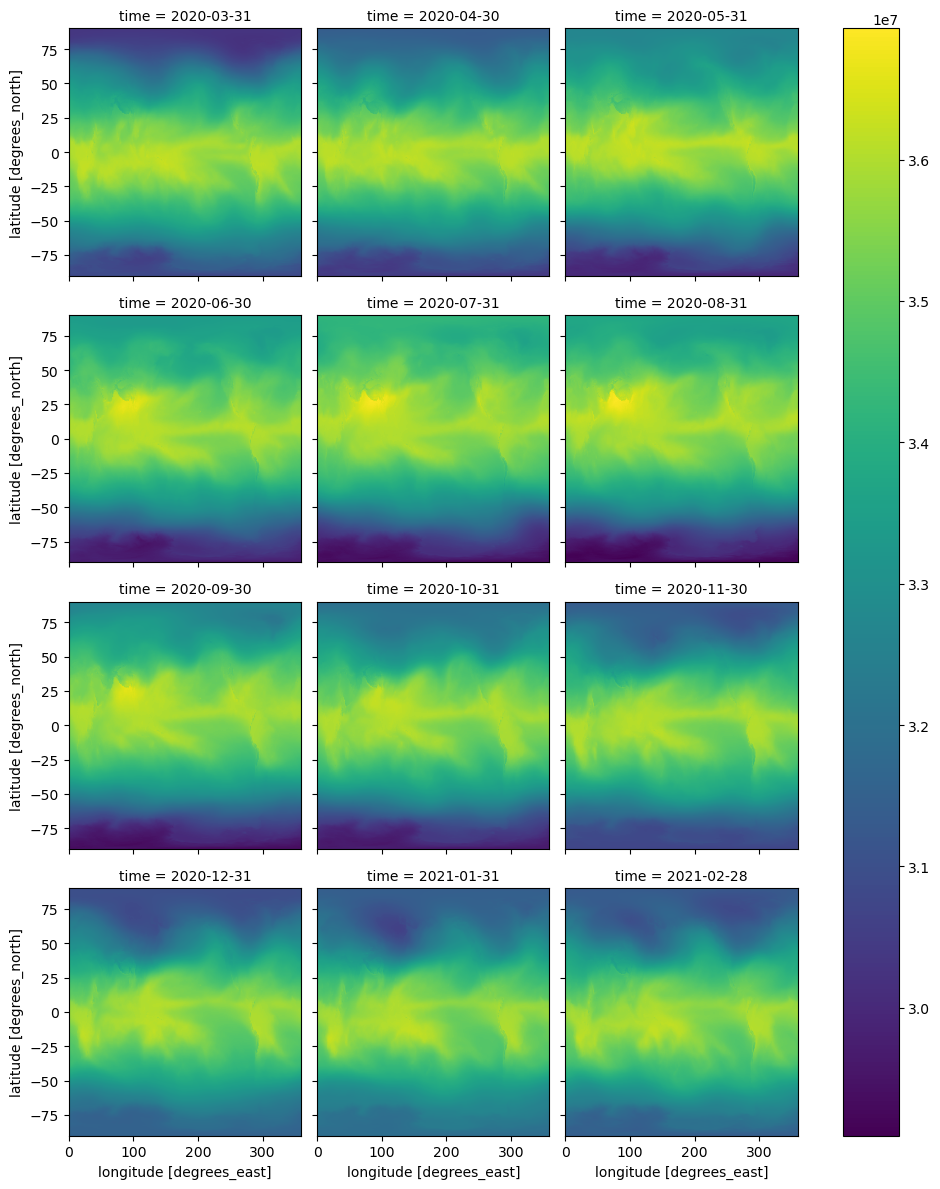

In [9]:
xr.open_dataarray("monthly_era5_MSE.nc").plot(col="time",col_wrap=3)

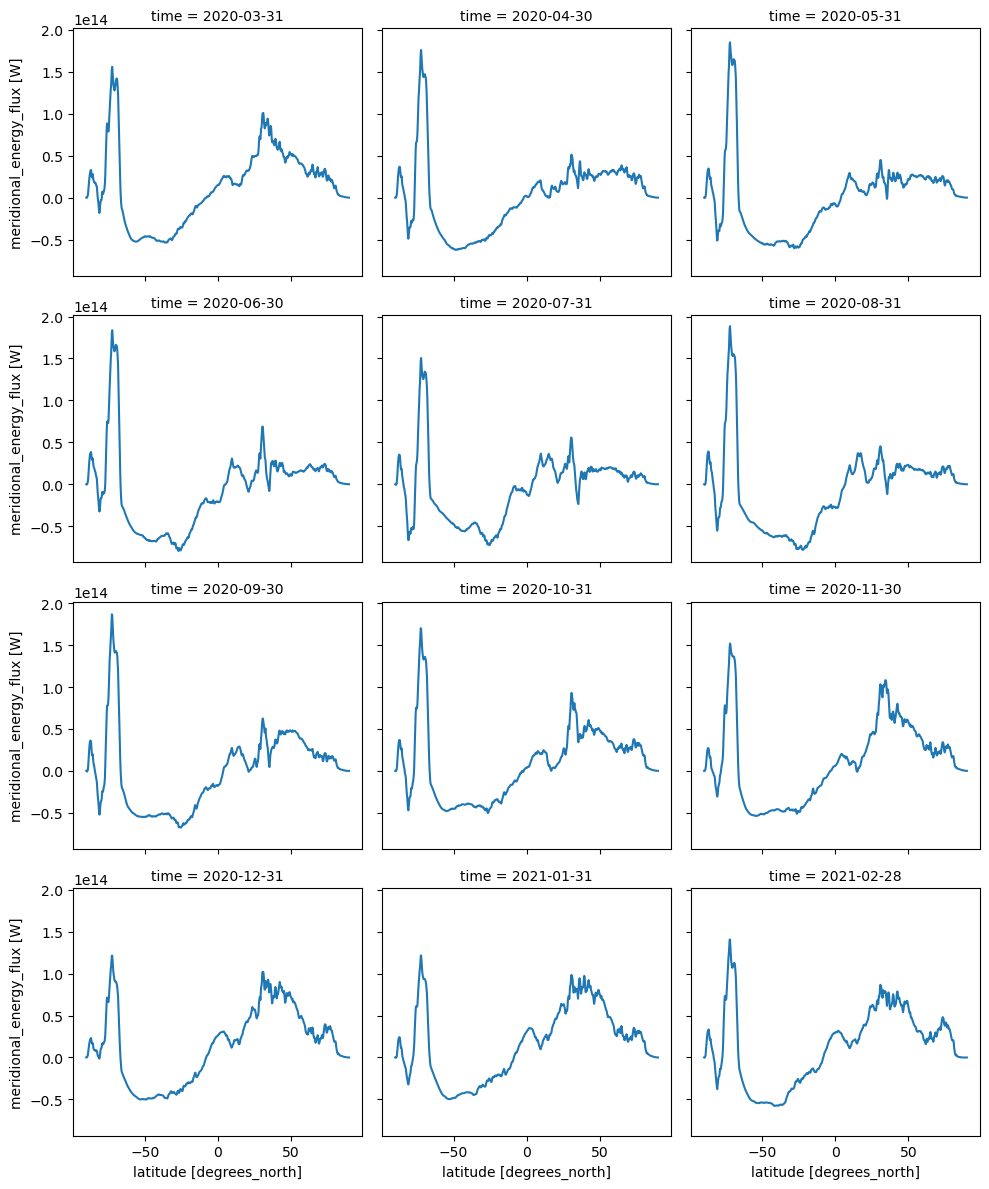

In [10]:
xr.open_dataarray("monthly_era5_MEF.nc").plot(col="time",col_wrap=3)


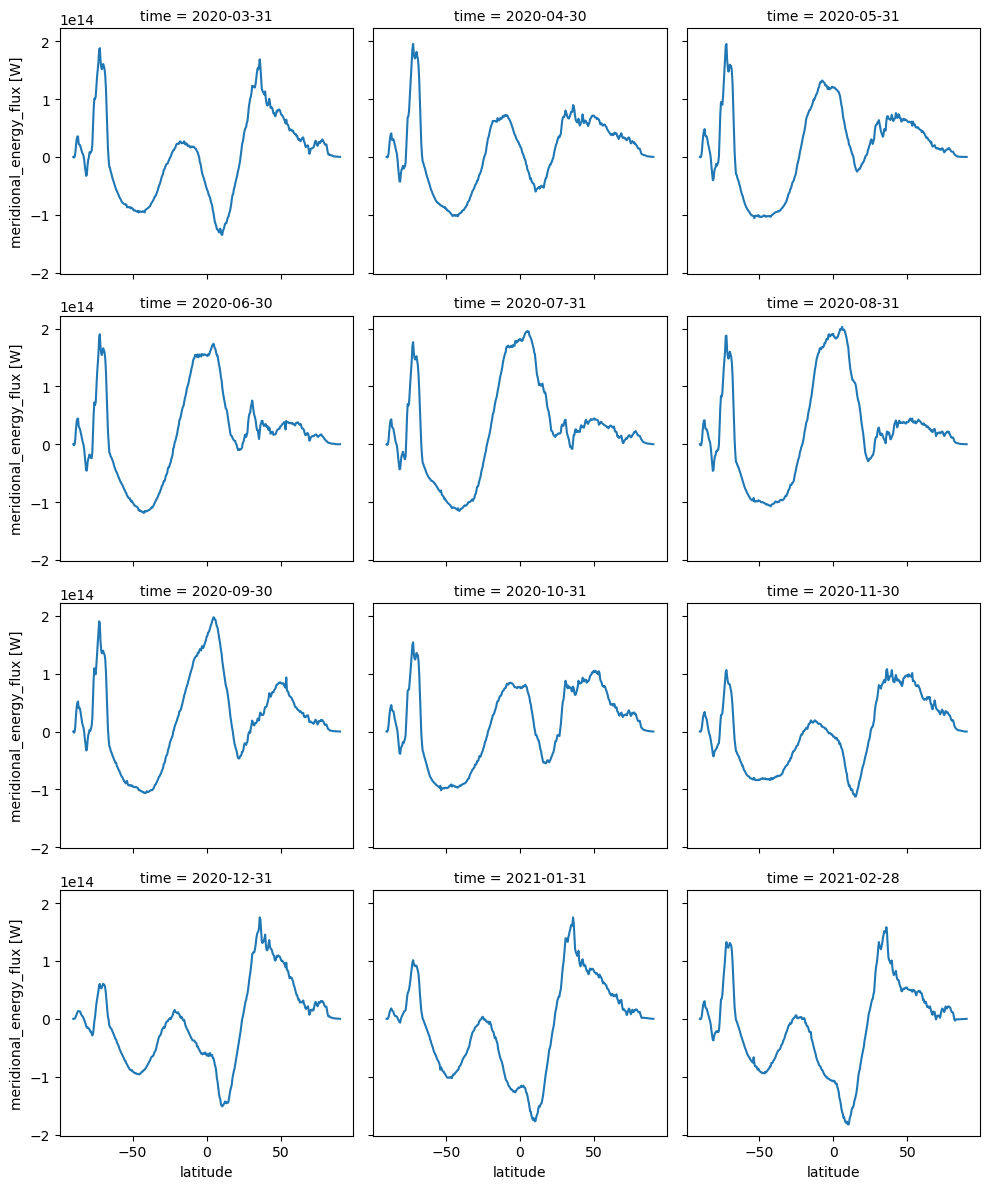

In [14]:
xr.open_dataarray("../monthly_um_glm_n2560_RAL3p3_tuned_hk26_MEF_zoom_7.nc").plot(
    col="time", col_wrap=3
)

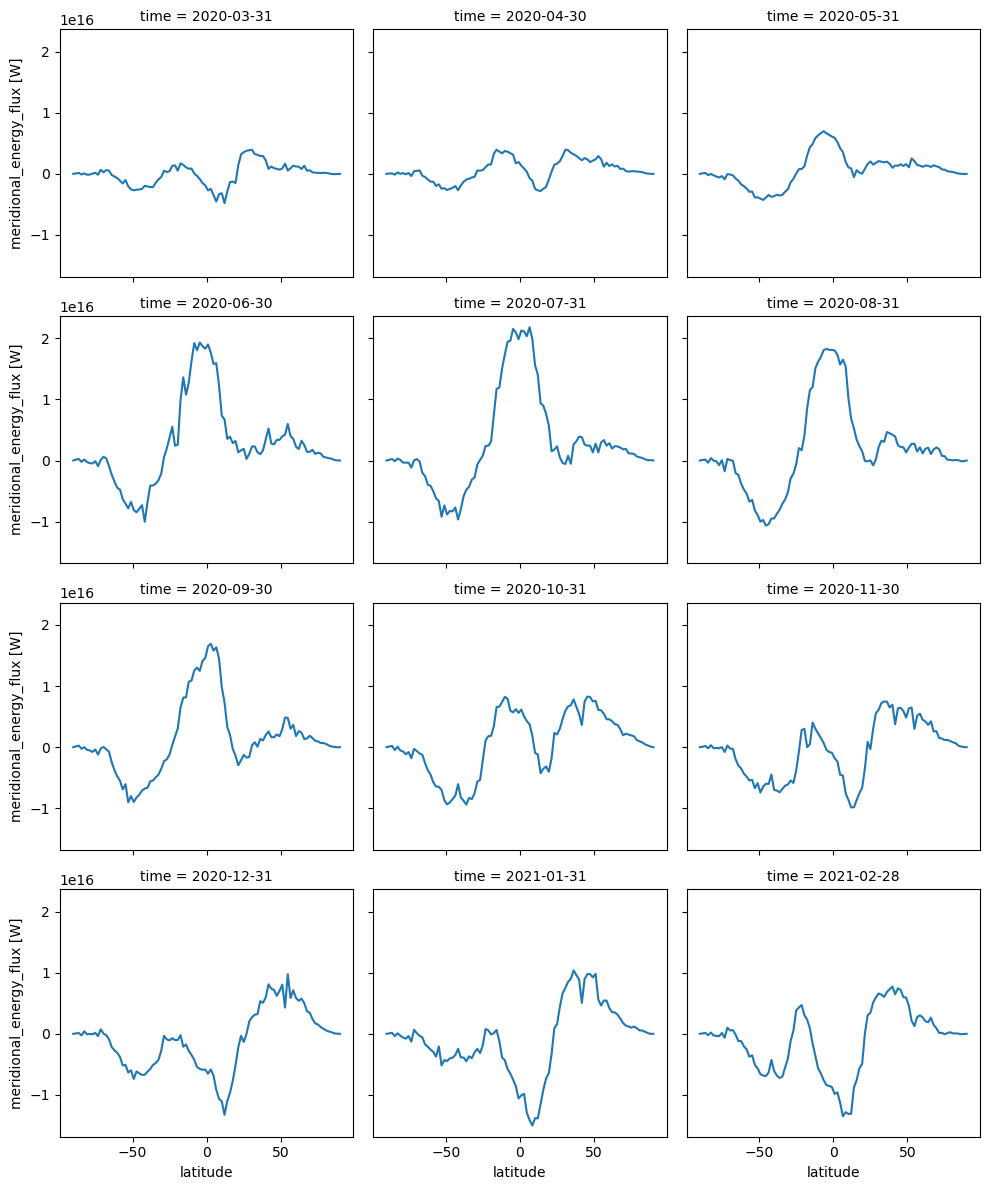

In [15]:
xr.open_dataarray("monthly_icon_d3hp003_MEF_zoom_5.nc").plot(
    col="time", col_wrap=3
)